   Customer_ID  Age  Gender  Tenure    Balance  CreditScore  EstimatedSalary  \
0            1   56  Female       3   78522.09          746        121327.42   
1            2   69    Male       1   23302.25          625         42653.26   
2            3   46  Female      10    7554.69          501         44595.43   
3            4   32    Male       6  161743.13          549        133980.26   
4            5   60  Female       6   47498.69          784        138474.41   

   NumOfProducts  IsActiveMember  Churn  
0              4               0      1  
1              1               0      1  
2              4               0      1  
3              4               1      0  
4              4               0      1  
Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64
Customer_ID          int64
Age              

/tmp/ipykernel_10270/3691419355.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby("AgeGroup")["Churn"].mean())


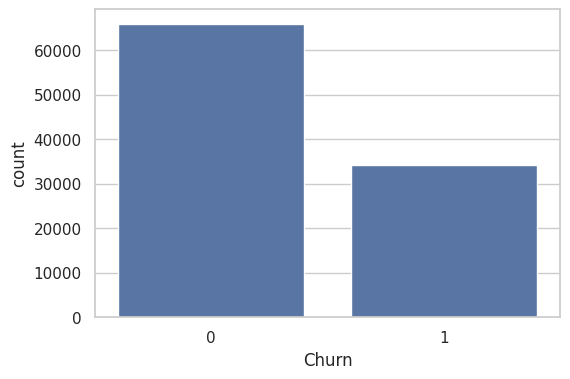

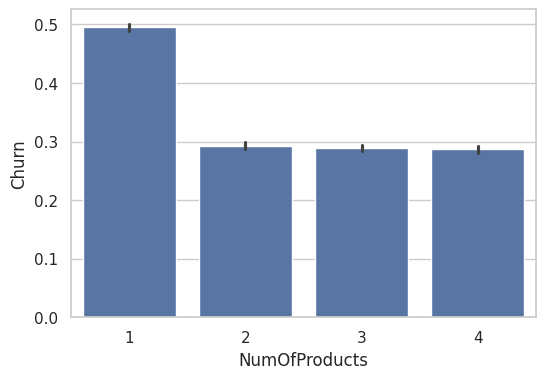

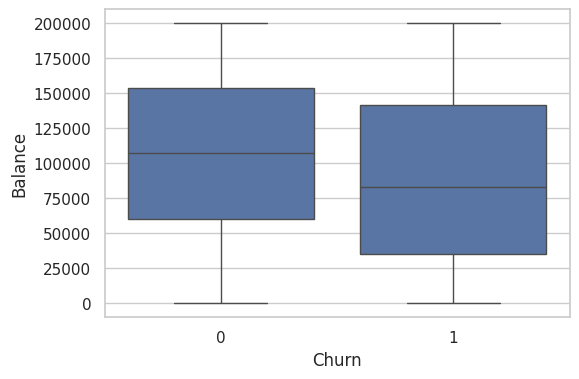

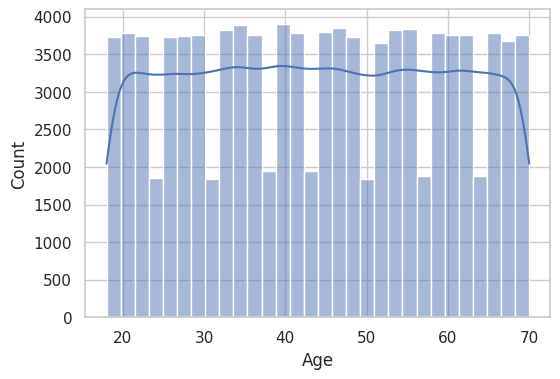

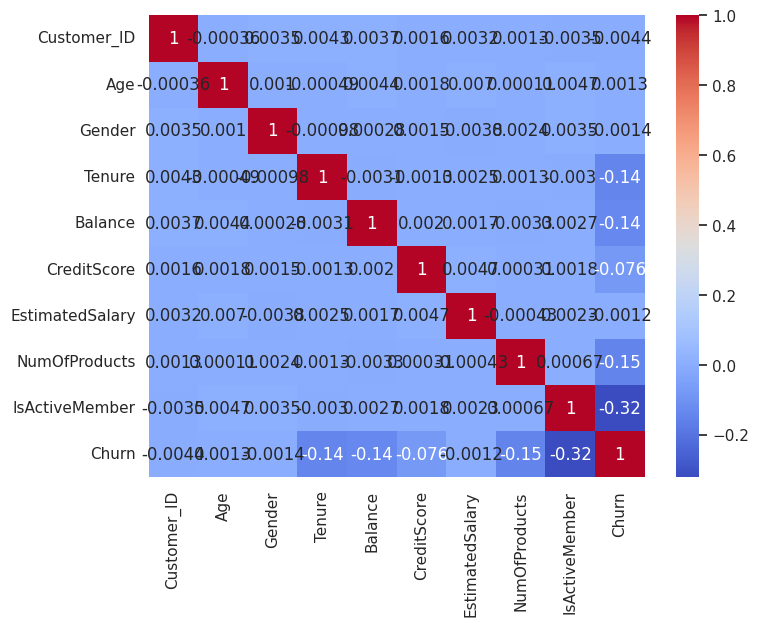

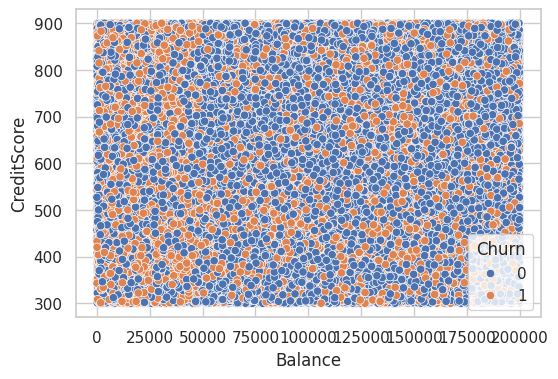

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

np.random.seed(42)
n = 100000

Customer_ID = np.arange(1, n+1)
Age = np.random.randint(18, 71, n)
Gender = np.random.choice(["Male", "Female"], n)
Tenure = np.random.randint(0, 11, n)
Balance = np.round(np.random.uniform(0, 200000, n), 2)
CreditScore = np.random.randint(300, 901, n)
EstimatedSalary = np.round(np.random.uniform(10000, 150000, n), 2)
NumOfProducts = np.random.randint(1, 5, n)
IsActiveMember = np.random.choice([0, 1], n)

data = pd.DataFrame({
    "Customer_ID": Customer_ID,
    "Age": Age,
    "Gender": Gender,
    "Tenure": Tenure,
    "Balance": Balance,
    "CreditScore": CreditScore,
    "EstimatedSalary": EstimatedSalary,
    "NumOfProducts": NumOfProducts,
    "IsActiveMember": IsActiveMember
})

prob = (
    0.3 * (data["IsActiveMember"] == 0) +
    0.2 * (data["NumOfProducts"] == 1) +
    0.2 * (data["Balance"] < 50000) +
    0.1 * (data["CreditScore"] < 500) +
    0.2 * (data["Tenure"] < 3)
)

data["Churn"] = (np.random.rand(n) < prob).astype(int)

print(data.head())
print(data.isnull().sum())
print(data.dtypes)

data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})

print(data.duplicated().sum())

print(data.describe())
print(data.median(numeric_only=True))
print(data.mode().iloc[0])
print(data.std(numeric_only=True))

print(data["Churn"].mean())
print(data.groupby("Churn").mean(numeric_only=True))

data["AgeGroup"] = pd.cut(data["Age"], bins=[18,30,40,50,60,70])

print(data.groupby("AgeGroup")["Churn"].mean())
print(data.groupby("Gender")["Churn"].mean())
print(data.groupby("IsActiveMember")["Churn"].mean())
print(data.groupby("NumOfProducts")["Churn"].mean())

corr = data.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=data)
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x="NumOfProducts", y="Churn", data=data)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Balance", data=data)
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data["Age"], bins=30, kde=True)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Balance", y="CreditScore", hue="Churn", data=data)
plt.show()